# exp09_regiones — bloques por REGIÓN administrativa de Tamaulipas

El estado entero (4384 nodos) no cabe en RAM: la curva medida en esta máquina da
**0.060 GB/nodo**, o sea ~263 GB. Hay que entrenar por bloques, y las 6 regiones
oficiales del estado son una partición con significado.

**Diseño**: se entrena sobre `región + halo de 3 celdas` (~13 km) y se **evalúa solo
sobre la región**. El halo existe porque cortar por una frontera administrativa rompe
los vecindarios espaciales — sin él, el 42 % de los nodos del estado pierde el
vecindario r2 completo, y `kt_vecinos_mean_r2` es la 2ª feature del modelo.

**v1 = Centro**, la región de Ciudad Victoria y la mayor del estado (1500 nodos).
Feature-set idéntico al de exp07 v4 para que la única variable sea el bloque de nodos.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from forecasting.experiments.reporte import ReporteExperimento
from forecasting.data.loaders import cargar_metadata
from forecasting.data import regiones as REG

r = ReporteExperimento.de('exp09_regiones', version='v1', ejecutar=False)
r.resumen()
print('\nentrena %d nodos · evalúa %d (halo %d)' % (
    r.config['n_nodos'], r.config['n_nodos_eval'],
    r.config['n_nodos'] - r.config['n_nodos_eval']))

exp09_regiones v1 | feature-set base-nocturno-viento-cielo-nubes-adveccion-adveccion_upwind_r23 (64 feats) | best_iter 657
Test global: RMSE 75.00 vs persist 88.66 | skill 0.1542 | R² 0.933

entrena 1894 nodos · evalúa 1500 (halo 394)


## Coste por región: qué cabe y qué no

Constantes de la curva medida (144/300/500/1000 nodos, R² 0.9995): pico 0.060 GB/nodo,
0.21 s/nodo. Son estimaciones en **float64**; con `float32` el pico real baja bastante.

In [2]:
tab = REG.resumen_regiones(radio_halo=3)
disponible = 119   # GB libres medidos en la máquina
tab['cabe'] = np.where(tab.RAM_GB_est < disponible, 'sí', 'NO')
display(tab)

,region,nodos,halo,total,RAM_GB_est,minutos_est,cabe
0,Centro,1500,394,1894,114,6.6,sí
1,Fronteriza,928,78,1006,61,3.5,sí
2,Valle de San Fernando,689,254,943,57,3.3,sí
3,Sur,483,214,697,42,2.4,sí
4,Altiplano,471,159,630,38,2.2,sí
5,Mante,313,221,534,33,1.9,sí


## Mapa: la región Centro, su halo y el resto del estado

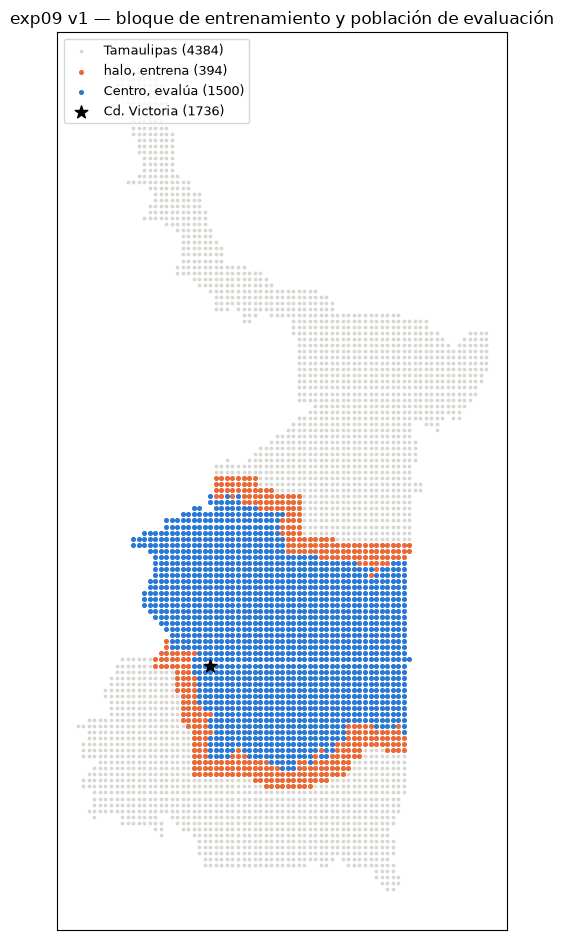

In [3]:
todos = cargar_metadata()
propios = set(REG.nodos_region('Centro'))
entrena, _ = REG.bloque_region('Centro', 3)
halo = set(entrena) - propios

fig, ax = plt.subplots(figsize=(7.5, 9.5))
ax.scatter(todos.longitude, todos.latitude, s=3, c='#d8d7d2', label='Tamaulipas (4384)')
h = todos[todos.nodo_id.isin(halo)]
p = todos[todos.nodo_id.isin(propios)]
ax.scatter(h.longitude, h.latitude, s=7, c='#eb6834', label=f'halo, entrena ({len(halo)})')
ax.scatter(p.longitude, p.latitude, s=7, c='#2a78d6', label=f'Centro, evalúa ({len(propios)})')
ax.scatter([todos.loc[todos.nodo_id==1736,'longitude']],
           [todos.loc[todos.nodo_id==1736,'latitude']], s=90, marker='*',
           c='k', zorder=5, label='Cd. Victoria (1736)')
ax.set_aspect(1/np.cos(np.deg2rad(24))); ax.legend(loc='upper left', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('exp09 v1 — bloque de entrenamiento y población de evaluación')
plt.tight_layout(); plt.show()

## ¿Gana el bloque grande? exp09 (1500 nodos) vs exp07 v4 (144)

Aviso metodológico: **no son la misma población de test**. exp07 v4 evalúa 144 nodos
alrededor de Victoria; exp09 evalúa los 1500 de Centro. El `RMSE_persistence` de cada
uno lo confirma. La comparación honesta es el skill *sobre los mismos nodos*, que es
lo que hace la celda siguiente.

In [4]:
v4 = ReporteExperimento.de('exp07_adveccion', version='v4', ejecutar=False)
filas = []
for nom, rep in [('exp07 v4 (144 nodos)', v4), ('exp09 v1 (1500 nodos)', r)]:
    g = rep.metrics_global; t = g[(g.split=='test') & (g.segmento=='global')].iloc[0]
    filas.append({'experimento': nom, 'n_eval': rep.config.get('n_nodos_eval', rep.config['n_nodos']),
                  'RMSE_modelo': round(t.RMSE_modelo, 2),
                  'RMSE_persistence': round(t.RMSE_persistence, 2),
                  'skill': round(t.skill, 4), 'R2': round(t.R2_modelo, 3)})
display(pd.DataFrame(filas))

,experimento,n_eval,RMSE_modelo,RMSE_persistence,skill,R2
0,exp07 v4 (144 nodos),144,75.4,86.41,0.1274,0.934
1,exp09 v1 (1500 nodos),1500,75.0,88.66,0.1542,0.933


In [5]:
# Comparación pareada: SOLO los nodos que ambos evalúan.
comunes = sorted(set(v4.por_nodo.nodo_id) & set(r.por_nodo.nodo_id))
a = v4.por_nodo.set_index('nodo_id').loc[comunes]
b = r.por_nodo.set_index('nodo_id').loc[comunes]
print('nodos comunes: %d' % len(comunes))
pareado = pd.DataFrame({
    'RMSE_exp07v4': a.RMSE_modelo, 'RMSE_exp09': b.RMSE_modelo,
    'skill_exp07v4': a.skill, 'skill_exp09': b.skill})
pareado['delta_skill'] = pareado.skill_exp09 - pareado.skill_exp07v4
print(pareado[['skill_exp07v4','skill_exp09','delta_skill']].mean().round(4).to_string())
print('\nnodos donde exp09 mejora: %d de %d' % ((pareado.delta_skill > 0).sum(), len(pareado)))
display(pareado.describe().round(4))

nodos comunes: 117
skill_exp07v4    0.1284
skill_exp09      0.1392
delta_skill      0.0109

nodos donde exp09 mejora: 94 de 117


,RMSE_exp07v4,RMSE_exp09,skill_exp07v4,skill_exp09,delta_skill
count,117.0000,117.0000,117.0000,117.0000,117.0000
mean,75.1496,74.2252,0.1284,0.1392,0.0109
std,4.7436,5.0522,0.0169,0.0223,0.0116
min,67.7547,67.3149,0.0712,0.0733,-0.0158
25%,71.7417,70.0542,0.1189,0.1239,0.0023
50%,74.3071,72.5899,0.1271,0.1398,0.0085
75%,77.8532,77.3558,0.1411,0.1557,0.0191
max,91.8879,92.6942,0.1640,0.1837,0.0393


## Distribución espacial del skill dentro de Centro

skill: min 0.065 · mediana 0.156 · max 0.215
correlación skill~msnm: -0.406


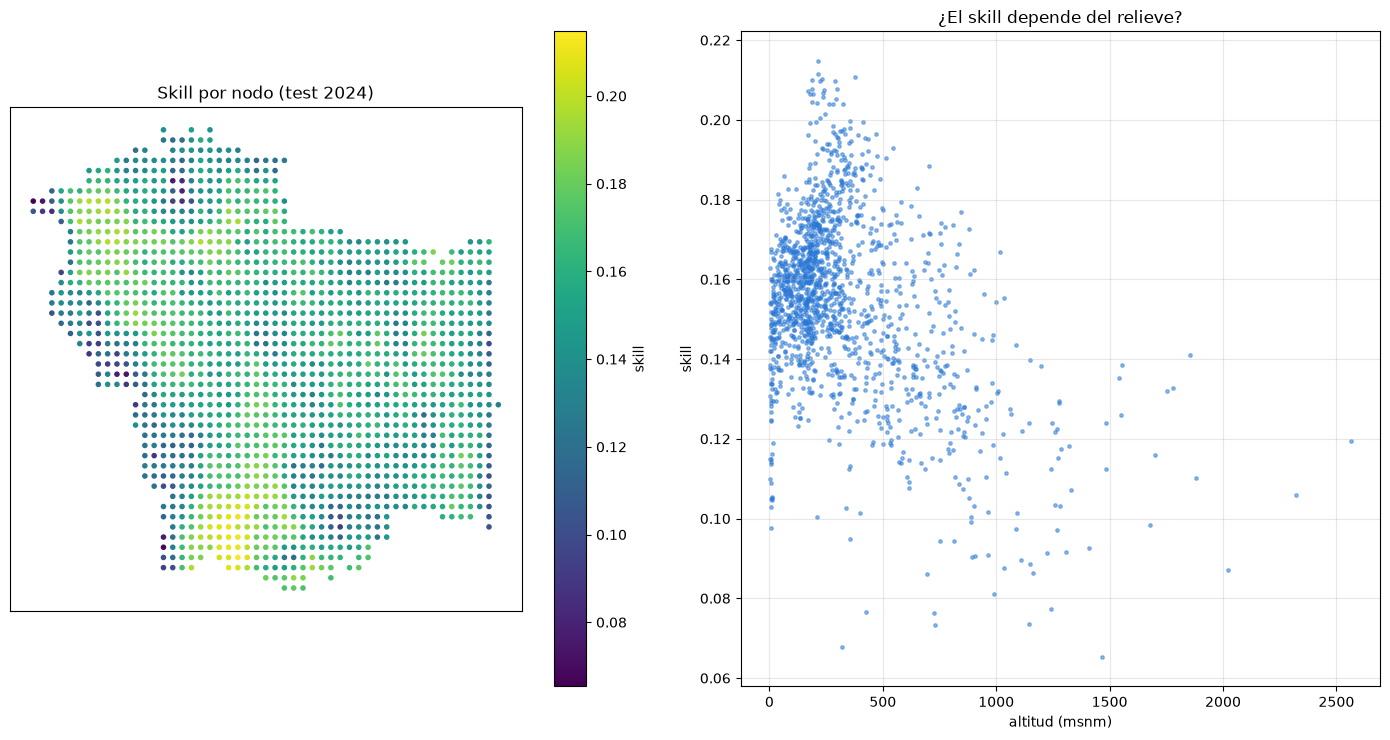

In [6]:
meta = cargar_metadata().set_index('nodo_id')
pn = r.por_nodo.set_index('nodo_id').join(meta[['latitude','longitude','msnm']])
fig, ax = plt.subplots(1, 2, figsize=(14, 7.5))
s = ax[0].scatter(pn.longitude, pn.latitude, c=pn.skill, s=9, cmap='viridis')
fig.colorbar(s, ax=ax[0], label='skill'); ax[0].set_title('Skill por nodo (test 2024)')
ax[0].set_aspect(1/np.cos(np.deg2rad(24))); ax[0].set_xticks([]); ax[0].set_yticks([])
ax[1].scatter(pn.msnm, pn.skill, s=6, alpha=.5, c='#2a78d6')
ax[1].set_xlabel('altitud (msnm)'); ax[1].set_ylabel('skill'); ax[1].grid(alpha=.3)
ax[1].set_title('¿El skill depende del relieve?')
print('skill: min %.3f · mediana %.3f · max %.3f' % (pn.skill.min(), pn.skill.median(), pn.skill.max()))
print('correlación skill~msnm: %.3f' % pn.skill.corr(pn.msnm))
plt.tight_layout(); plt.show()

## Régimen de nubosidad y de rampa

In [7]:
display(r.regimen_nubosidad.round(3))
display(r.regimen_rampa.round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),440041,131.435,132.125,96.237,-3.266,0.005
1,parcial (0.3-0.7),1126590,106.902,129.134,76.832,0.580,0.172
2,despejado (kt>=0.7),4616672,55.657,69.252,31.576,0.959,0.196


,regimen_rampa,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,rampa suave (<0.1),4206667,40.683,23.471,24.371,0.980,-0.733
1,rampa moderada (0.1-0.25),1194435,88.492,102.974,67.926,0.876,0.141
2,rampa fuerte (>0.25),780701,153.767,207.530,116.543,0.548,0.259


## Importancias — ¿siguen mandando los vecinos con 12× más nodos?

,index,gain,rank
0,kt_lag1,0.507498,1
1,kt_vecinos_mean,0.129854,2
2,kt_vecinos_mean_r3,0.124168,3
3,cloud_op_vecinos_mean,0.074116,4
4,kt_vecinos_mean_r2,0.022268,5
10,kt_upwind,0.004235,11
11,cloud_op_lag1,0.003843,12
12,cloud_op_media_12h,0.003779,13
29,kt_vecinos_std,0.002211,30


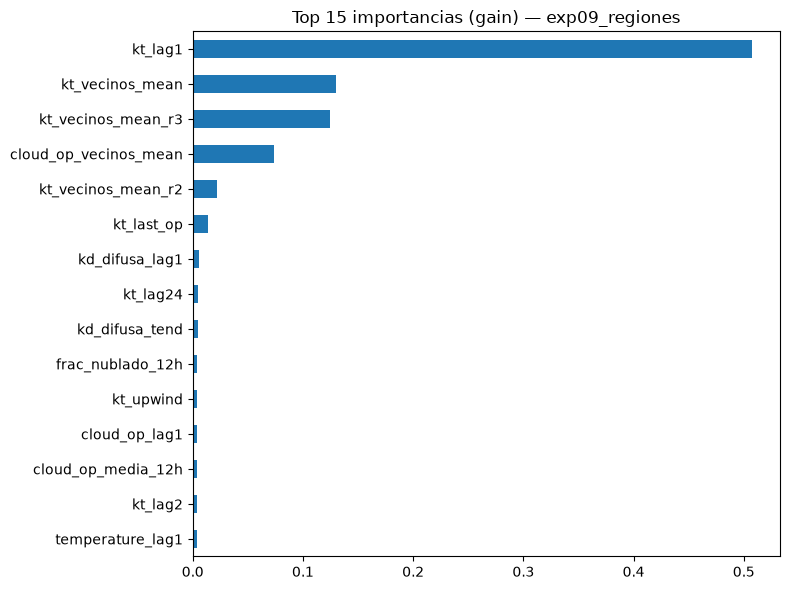

In [8]:
imp = r.importancias.reset_index(); imp['rank'] = range(1, len(imp)+1)
display(imp[imp['index'].str.contains('vecinos|upwind|kt_lag1|cloud_op')][['index','gain','rank']])
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Métricas globales

In [9]:
display(r.metrics_global.round(3))

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,6168797,90.017,75.495,42.346,3.162,0.908,0.936,0.161,val
1,limpio_ff0,5629064,91.772,76.871,43.104,2.360,0.899,0.929,0.162,val
2,rellenado_ff_pos,539733,69.099,59.281,34.443,11.527,0.864,0.900,0.142,val
3,global,6183303,88.664,74.996,44.423,1.347,0.906,0.933,0.154,test
4,limpio_ff0,5604787,90.110,76.244,45.485,1.272,0.897,0.926,0.154,test
5,rellenado_ff_pos,578516,73.191,61.611,34.140,2.079,0.867,0.906,0.158,test


## Las 6 regiones — estado completo

Cada versión evalúa una **población distinta**, así que los skills no son comparables
entre sí de forma directa: el `RMSE_persistence` de cada región mide lo difícil que es
esa región, no lo bueno que es su modelo.

In [10]:
import json
filas, pornodo = [], []
for i, region in enumerate(REG.REGIONES, start=1):
    rr = ReporteExperimento.de('exp09_regiones', version=f'v{i}', ejecutar=False)
    g = rr.metrics_global; t = g[(g.split=='test') & (g.segmento=='global')].iloc[0]
    ram = rr.regimen_rampa
    pn = rr.por_nodo.copy(); pn['region'] = region; pornodo.append(pn)
    filas.append({'v': f'v{i}', 'region': region, 'nodos': rr.config['n_nodos_eval'],
                  'halo': rr.config['n_nodos'] - rr.config['n_nodos_eval'],
                  'RMSE_persist': round(t.RMSE_persistence, 2),
                  'RMSE_mod': round(t.RMSE_modelo, 2), 'skill': round(t.skill, 4),
                  'R2': round(t.R2_modelo, 3), 'best_iter': rr.config['best_iteration'],
                  'skill_rampa_fuerte': round(ram[ram.regimen_rampa.str.startswith('rampa fuerte')].iloc[0].skill, 3)})
tabla = pd.DataFrame(filas)
meta = cargar_metadata().set_index('nodo_id')
tabla['msnm'] = [round(meta.loc[list(REG.nodos_region(r)), 'msnm'].mean()) for r in tabla.region]
P = pd.concat(pornodo, ignore_index=True).merge(meta[['latitude','longitude','msnm']],
                                                left_on='nodo_id', right_index=True)
display(tabla)
print('nodos evaluados en total: %d de 4384' % len(P))
print('nodos con skill<0: %d' % (P.skill < 0).sum())

,v,region,nodos,halo,RMSE_persist,RMSE_mod,skill,R2,best_iter,skill_rampa_fuerte,msnm
0,v1,Centro,1500,394,88.66,75.00,0.1542,0.933,657,0.259,327
1,v2,Fronteriza,928,78,87.61,74.80,0.1463,0.928,275,0.246,70
2,v3,Valle de San Fernando,689,254,86.29,73.56,0.1475,0.933,312,0.244,113
3,v4,Sur,483,214,91.69,76.59,0.1647,0.926,454,0.276,118
4,v5,Altiplano,471,159,87.80,75.82,0.1364,0.934,1037,0.239,1543
5,v6,Mante,313,221,84.03,71.34,0.1510,0.939,515,0.268,325


nodos evaluados en total: 4384 de 4384
nodos con skill<0: 0


### El relieve es el factor discriminante

El tamaño del bloque no explica nada del skill entre regiones; la altitud sí.

  skill ~ msnm          (entre regiones): -0.687
  skill ~ RMSE_persist  (entre regiones): +0.516
  skill ~ nodos         (entre regiones): +0.102
  skill ~ best_iter     (entre regiones): -0.458
  skill ~ msnm          (por nodo, n=4384): -0.303


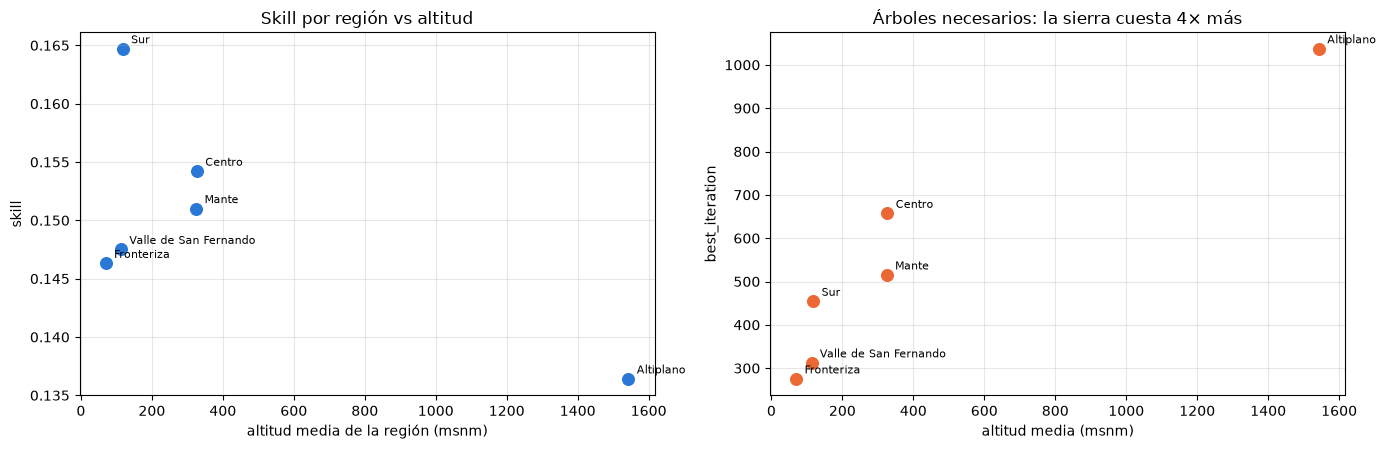

In [11]:
for col in ['msnm', 'RMSE_persist', 'nodos', 'best_iter']:
    print('  skill ~ %-13s (entre regiones): %+.3f' % (col, tabla.skill.corr(tabla[col])))
print('  skill ~ msnm          (por nodo, n=%d): %+.3f' % (len(P), P.skill.corr(P.msnm)))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].scatter(tabla.msnm, tabla.skill, s=70, c='#2a78d6')
for _, f in tabla.iterrows():
    ax[0].annotate(f.region, (f.msnm, f.skill), fontsize=8,
                   xytext=(6, 4), textcoords='offset points')
ax[0].set_xlabel('altitud media de la región (msnm)'); ax[0].set_ylabel('skill')
ax[0].grid(alpha=.3); ax[0].set_title('Skill por región vs altitud')
ax[1].scatter(tabla.msnm, tabla.best_iter, s=70, c='#eb6834')
for _, f in tabla.iterrows():
    ax[1].annotate(f.region, (f.msnm, f.best_iter), fontsize=8,
                   xytext=(6, 4), textcoords='offset points')
ax[1].set_xlabel('altitud media (msnm)'); ax[1].set_ylabel('best_iteration')
ax[1].grid(alpha=.3); ax[1].set_title('Árboles necesarios: la sierra cuesta 4× más')
plt.tight_layout(); plt.show()

### Mapa del estado completo

Ver también `Results/Tamaulipas/skill_regiones_tamaulipas.png`.

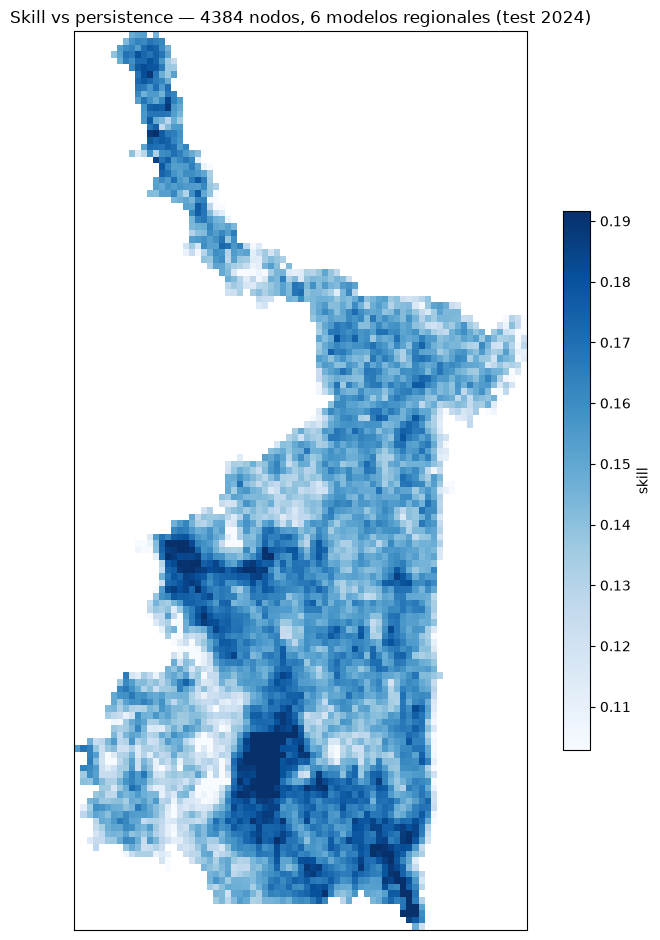

In [12]:
ilat = ((P.latitude - P.latitude.min())/0.04).round().astype(int)
ilon = ((P.longitude - P.longitude.min())/0.04).round().astype(int)
M = np.full((ilat.max()+1, ilon.max()+1), np.nan); M[ilat, ilon] = P.skill
fig, ax = plt.subplots(figsize=(7.5, 9.5))
im = ax.imshow(np.ma.masked_invalid(M), origin='lower', interpolation='nearest', cmap='Blues',
               vmin=P.skill.quantile(.02), vmax=P.skill.quantile(.98),
               extent=[P.longitude.min()-.02, P.longitude.max()+.02,
                       P.latitude.min()-.02, P.latitude.max()+.02], aspect='auto')
fig.colorbar(im, ax=ax, label='skill', shrink=.6)
ax.set_aspect(1/np.cos(np.deg2rad(24))); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Skill vs persistence — 4384 nodos, 6 modelos regionales (test 2024)')
plt.tight_layout(); plt.show()

### Los dos agujeros estructurales

Rampa suave y cubierto fallan **igual en las seis regiones** — llanura costera,
frontera y sierra por igual. No es un problema de datos ni de escala: es del enfoque.

In [13]:
reg_tab = []
for i, region in enumerate(REG.REGIONES, start=1):
    rr = ReporteExperimento.de('exp09_regiones', version=f'v{i}', ejecutar=False)
    fila = {'region': region}
    for _, f in rr.regimen_rampa.iterrows():
        fila[f.regimen_rampa.split(' (')[0]] = round(f.skill, 3)
    for _, f in rr.regimen_nubosidad.iterrows():
        fila[f.regimen_nubosidad.split(' (')[0]] = round(f.skill, 3)
    reg_tab.append(fila)
display(pd.DataFrame(reg_tab).set_index('region'))

,rampa suave,rampa moderada,rampa fuerte,cubierto,parcial,despejado
region,,,,,,
Centro,-0.733,0.141,0.259,0.005,0.172,0.196
Fronteriza,-0.704,0.129,0.246,-0.024,0.137,0.214
Valle de San Fernando,-0.674,0.136,0.244,-0.003,0.154,0.195
Sur,-0.786,0.150,0.276,-0.073,0.137,0.254
Altiplano,-0.661,0.143,0.239,-0.015,0.177,0.161
Mante,-0.731,0.145,0.268,-0.088,0.141,0.232
